In [125]:
# imports

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.linear_model import LinearRegression

In [126]:
# Data imports & manipulations
path = "data/"
files = glob.glob(path + "*.csv")

df_list = [pd.read_csv(f) for f in files]
big_df = pd.concat(df_list, ignore_index=True)

print(big_df.head())

              ITEMS SALES AMOUNT PERCENTAGE  QUANTITY
0              7-Up        22.44     0.035%      12.0
1  Almond Croissant       238.50     0.377%      53.0
2       Almond milk        38.25     0.060%      51.0
3       Americano L       251.25     0.397%      45.0
4       Americano M       217.50     0.344%      43.0


In [127]:
big_df["SALES AMOUNT"] = (big_df["SALES AMOUNT"].astype(str).str.replace(",", "").astype(float))
print(big_df["SALES AMOUNT"])

0        22.44
1       238.50
2        38.25
3       251.25
4       217.50
         ...  
1632    164.00
1633    159.00
1634      5.10
1635     44.00
1636     43.00
Name: SALES AMOUNT, Length: 1637, dtype: float64


In [128]:
totals = big_df.groupby("ITEMS").agg({"SALES AMOUNT": "sum", "QUANTITY": "sum"}).reset_index()
totals.to_csv("Data/6_month_sales.csv", index=False)

print(totals.head(10))


              ITEMS  SALES AMOUNT  QUANTITY
0               111       4939.00     772.0
1              1111       1590.00     232.0
2              7-Up        403.92     216.0
3  Almond Croissant       5017.50    1115.0
4       Almond milk        588.75     785.0
5       Americano L       1830.75     327.0
6       Americano M       2985.50     593.0
7       Americano S        533.00     124.0
8       Apple Juice       2120.58     567.0
9     Avocado Toast      27376.25    1799.0


Top 10 Sales/Quantity

/var/folders/lc/3hhxzvlj1l77j_p4_lpshync0000gn/T/ipykernel_72533/175224348.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_sales, x = "SALES AMOUNT", y = "ITEMS", palette= "magma")


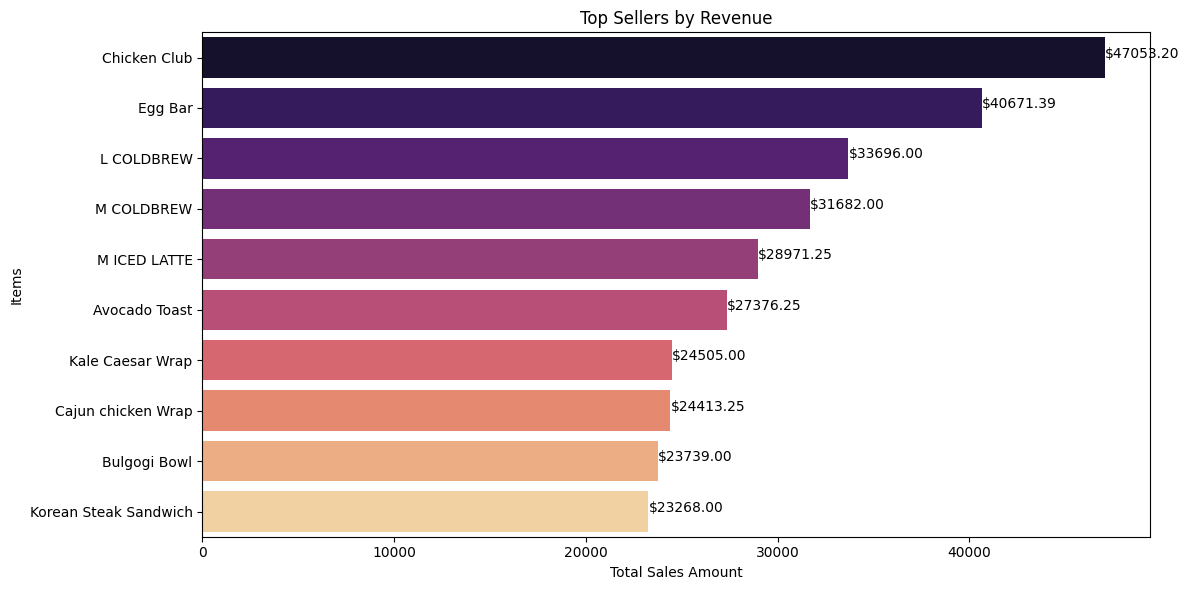

/var/folders/lc/3hhxzvlj1l77j_p4_lpshync0000gn/T/ipykernel_72533/175224348.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_quantity, x = "QUANTITY", y = "ITEMS", palette= "viridis")


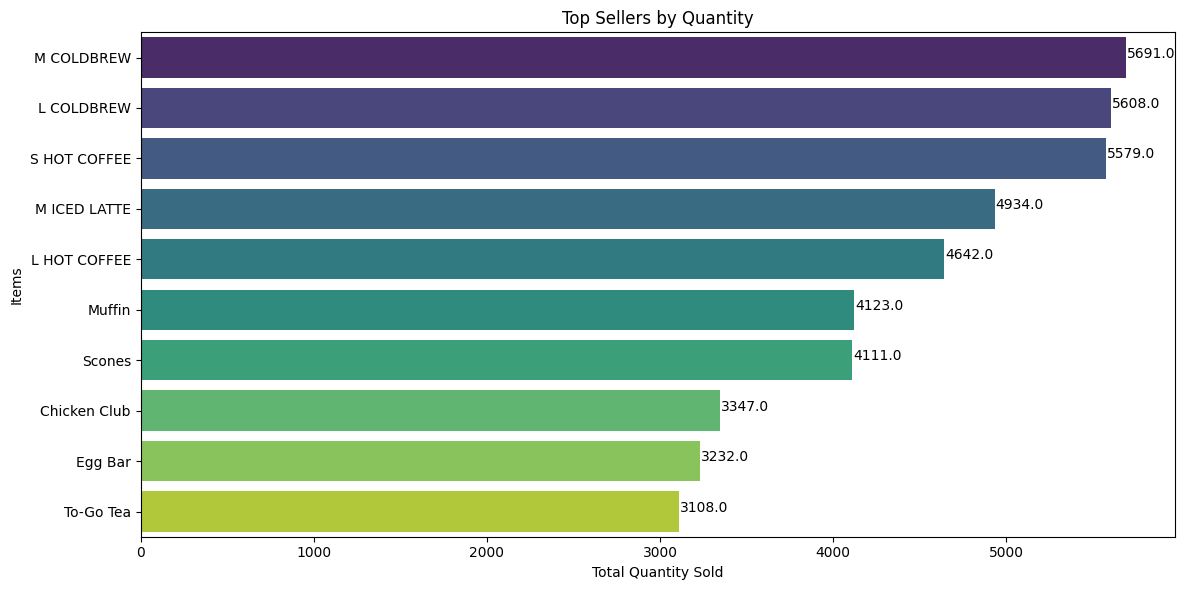

In [129]:
all_months = pd.read_csv("Data/6_month_sales.csv")

months = {"April" : pd.read_csv("Data/April_sales.csv"),
         "May" : pd.read_csv("Data/May_sales.csv"),
         "June" : pd.read_csv("Data/June_sales.csv"),
         "July" : pd.read_csv("Data/July_sales.csv"),
         "August" : pd.read_csv("Data/August_sales.csv"),
         "September" : pd.read_csv("Data/September_sales.csv")}

for month, df in months.items():
   df["SALES AMOUNT"] = (df["SALES AMOUNT"].astype(str).str.replace(",", "").astype(float))
   df["Month"] = month
   
monthly_df = pd.concat(months.values(), ignore_index=True)

# top sellers by revenue

top_sales = totals.sort_values("SALES AMOUNT", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data = top_sales, x = "SALES AMOUNT", y = "ITEMS", palette= "magma")
plt.title("Top Sellers by Revenue")
plt.xlabel("Total Sales Amount")
plt.ylabel("Items")

for index, value in enumerate(top_sales["SALES AMOUNT"]):
   plt.text(value + 5, index, f"${value:.2f}")
   
plt.tight_layout()
plt.show()

#------------------------------------
#top quantity

top_quantity = totals.sort_values("QUANTITY", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data = top_quantity, x = "QUANTITY", y = "ITEMS", palette= "viridis")
plt.title("Top Sellers by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Items")

for index, value in enumerate(top_quantity["QUANTITY"]):
   plt.text(value + 5, index, f"{value}")
   
plt.tight_layout()
plt.show()





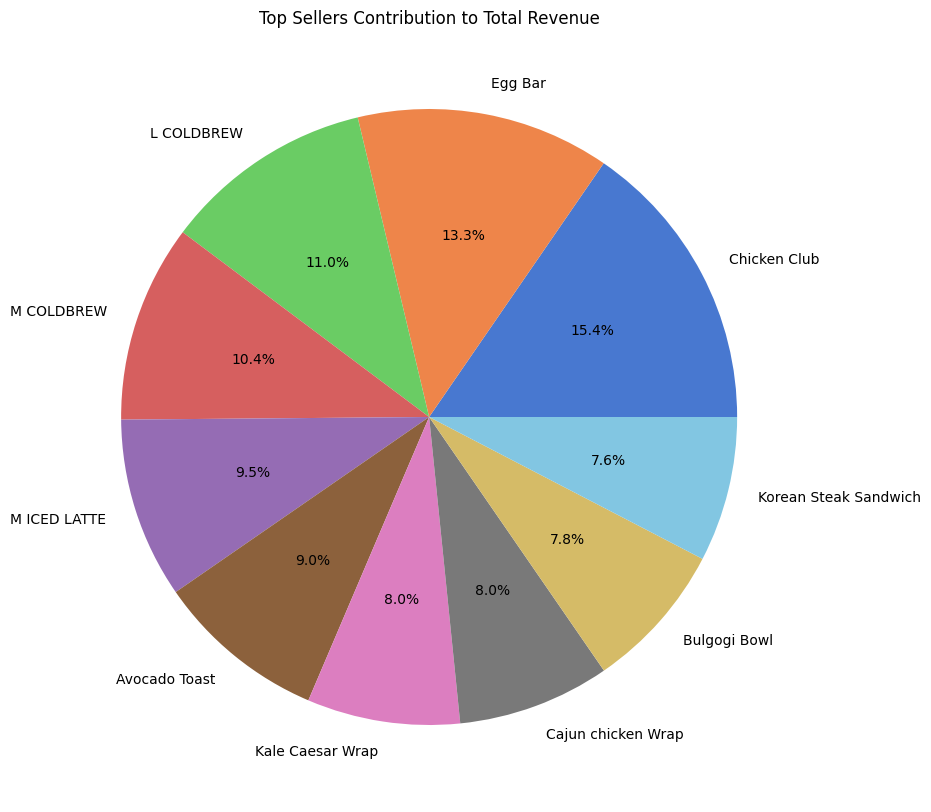

In [130]:
totals["Percent"] = totals["SALES AMOUNT"] / totals["SALES AMOUNT"].sum() * 100
top_contributor = totals.sort_values("Percent", ascending=False).head(10)

colors = sns.color_palette("muted", len(top_contributor)
                           )
plt.figure(figsize=(10,10))
plt.pie(top_contributor["Percent"], labels=top_contributor["ITEMS"], autopct="%1.1f%%", colors=colors)
plt.title("Top Sellers Contribution to Total Revenue")
plt.show()


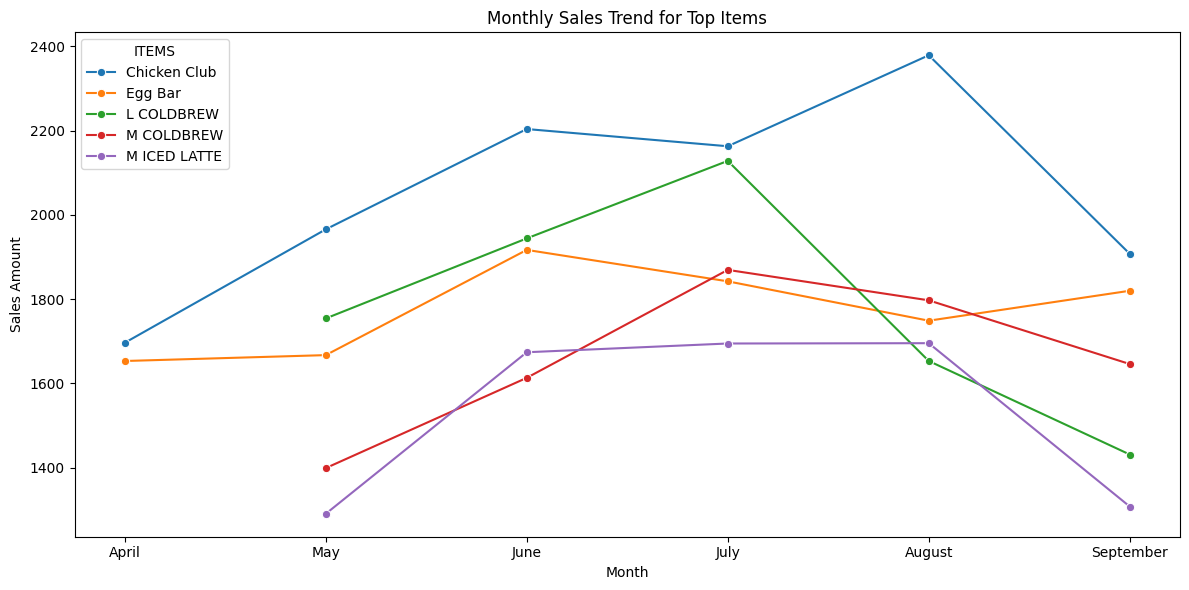

In [131]:
# Monthly trend lines

top_items = top_sales["ITEMS"].head(5)
trend = monthly_df[monthly_df["ITEMS"].isin(top_items)]

                           
plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x="Month", y="SALES AMOUNT", hue="ITEMS", marker="o")
plt.title("Monthly Sales Trend for Top Items")
plt.ylabel("Sales Amount")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

Monthly Revenue

In [132]:
monthly_revenue = []
for name, df in months.items():
      df["SALES AMOUNT"] = (df["SALES AMOUNT"].astype(str).str.replace(",", "").astype(float))
      monthly_revenue.append({"Month" : name, "Revenue" : df["SALES AMOUNT"].sum()})
      
revenue = pd.DataFrame(monthly_revenue)
print(revenue)

       Month   Revenue
0      April  51480.37
1        May  57358.98
2       June  63253.87
3       July  55559.62
4     August  54788.31
5  September  53424.90


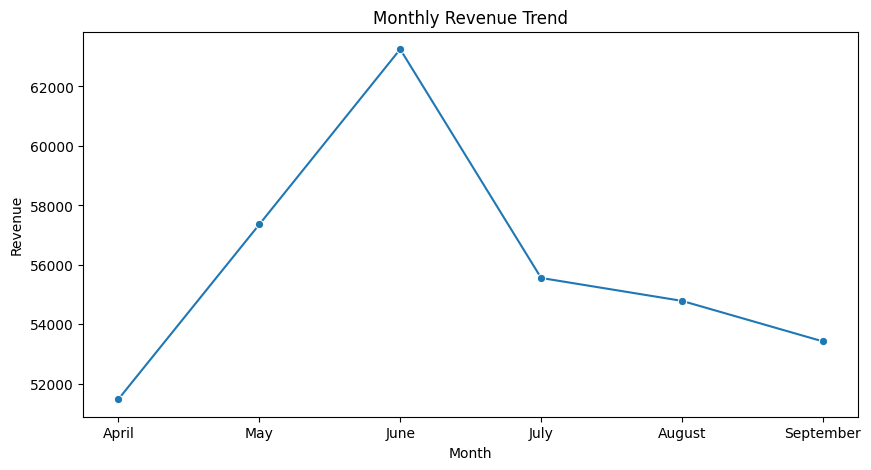

In [133]:
plt.figure(figsize=(10,5))
sns.lineplot(data=revenue, x="Month", y="Revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.show()

In [134]:
revenue["Forecast_MA"] = revenue["Revenue"].rolling(window=2).mean()
print(revenue)

       Month   Revenue  Forecast_MA
0      April  51480.37          NaN
1        May  57358.98    54419.675
2       June  63253.87    60306.425
3       July  55559.62    59406.745
4     August  54788.31    55173.965
5  September  53424.90    54106.605


In [135]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    revenue["Revenue"],
    trend="add",
    seasonal="add",
    seasonal_periods=2
).fit()

forecast = model.forecast(4) # -> 4 month prediction

future_months = ["September", "October", "November", "December"]
forecast_df = pd.DataFrame({"Month" : future_months, "Forecast" : forecast})

 
print(forecast_df)

       Month      Forecast
6  September  56194.542713
7    October  55134.848663
8   November  56038.065938
9   December  54978.371889


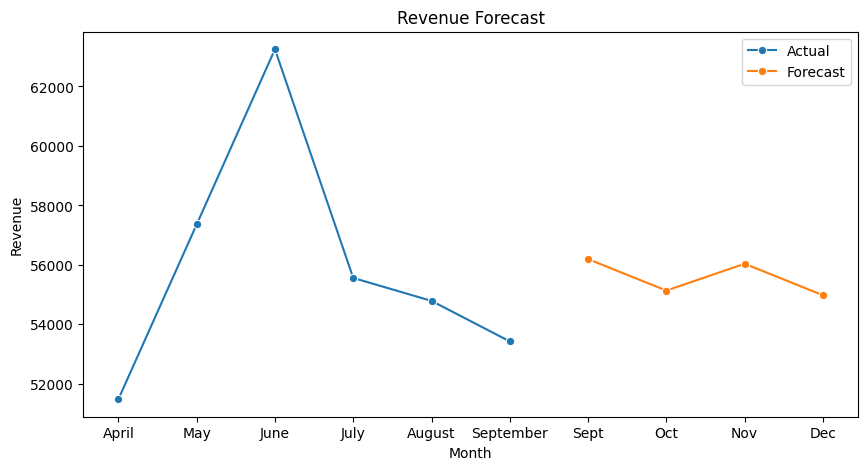

In [136]:
plt.figure(figsize=(10,5))
sns.lineplot(x=revenue["Month"], y=revenue["Revenue"], marker="o", label="Actual")
sns.lineplot(x=["Sept","Oct","Nov", "Dec"], y=forecast, marker="o", label="Forecast")
plt.title("Revenue Forecast")
plt.show()